# 第5章 図形と統計

 * 左上の「ファイル」を開いて、「ドライブにコピーを保存」をしてください。
 * 自分のGoogleドライブに、そのファイルが保存されます。ファイル名は「のコピー」が、最後（右端）についています。それを利用して学習・演習を進めて下さい。

# 5.4 相関

## 相関係数

例えば、10人のグループの出席番号順のテストの点が 10, 30, 50, 60, 70, 70, 80, 80, 90, 100 であり、レポートの点が 3, 5, 6, 7, 8, 7, 9, 8, 9, 10 であったとする。これは、どのような関係にあるだろうか。

まずは図示させる。matplotlib を利用する。


【プログラム5401】

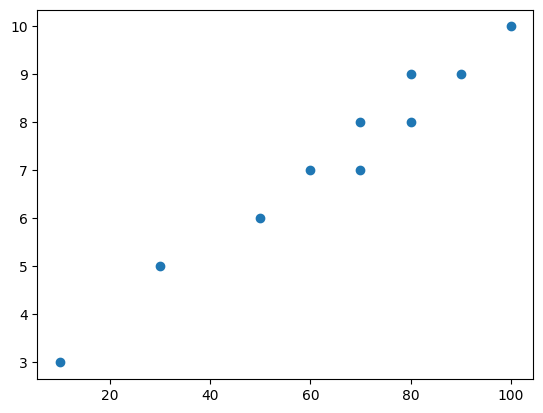

In [1]:
# モジュール matplotlib は、図示のときに用いる
import matplotlib.pyplot as plt

testscore = (10, 30, 50, 60, 70, 70, 80, 80, 90, 100)
reportscore = (3, 5, 6, 7, 8, 7, 9, 8, 9, 10)

# pyplot.scatter は、散布図を描く
plt.scatter(testscore, reportscore)

グラフからは正の相関があるだろうという予想がつく。
相関係数を求める。

【プログラム5402】

In [3]:
# numpy の相関係数を求める関数を利用する
import numpy as np
np.corrcoef(testscore, reportscore) # correlation coefficients

array([[1.        , 0.98377168],
       [0.98377168, 1.        ]])

相関係数は2行2列の表の形で得られる。

### 確認問題　（確認問題の正答はありません。授業中に提示します）

気象庁より取得した千葉市の2022年4月の1ヶ月の最高気温と日照時間のデータを用いて、散布図を書き、相関係数を求めよ。

array([[ 1.        , -0.28962103],
       [-0.28962103,  1.        ]])

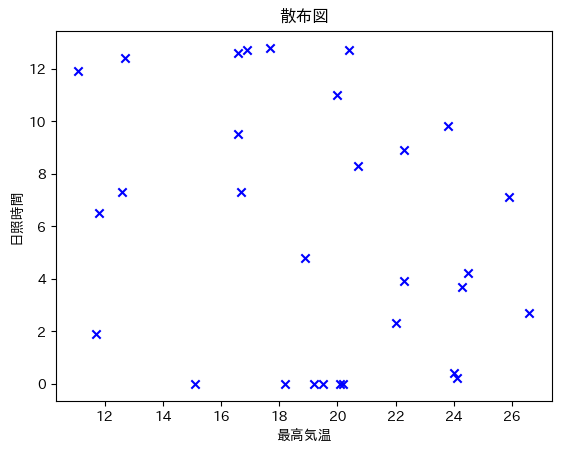

In [4]:
# モジュール matplotlib は、図示のときに用いる
import matplotlib.pyplot as plt
import numpy as np
!pip install japanize-matplotlib
import japanize_matplotlib

htemp = (11.1, 12.7, 12.6, 11.7, 16.7, 20.1, 17.7,
        20.0, 22.0, 24.5, 22.3, 22.3, 23.8, 20.4,
        11.8, 18.2, 16.9, 19.5, 19.2, 15.1, 20.2,
        24.0, 26.6, 20.7, 25.9, 24.1, 24.3, 18.9,
        16.6, 16.6)

stime = (11.9, 12.4,  7.3,  1.9, 7.3,  0.0, 12.8, 11.0,  2.3,  4.2,
          8.9,  3.9,  9.8, 12.7, 6.5,  0.0, 12.7,  0.0,  0.0,  0.0,
          0.0,  0.4,  2.7,  8.3, 7.1,  0.2,  3.7,  4.8, 12.6,  9.5,
        )

# 以下各自

plt.scatter(htemp,stime, marker="x", color="blue")
plt.xlabel("最高気温")
plt.ylabel("日照時間")
plt.title("散布図")

np.corrcoef(htemp,stime)

## seabornを利用した相関分析

箱ひげ図は、それぞれの項目の分布を知るために有効であるが、それぞれの項目の関連はわからない。
いま、もとのデータが出席番号順であるとして、例えば、「数学が得意な生徒は英語も得意か？」「数学が得意な生徒は情報も得意か？」「英語が得意な生徒は情報も得意か？」ということを知るためには、それぞれの相関係数を求める必要がある。

Python では、このような複数のデータの相関を求め、図示するために、seaborn というモジュールがあり、機能として、 corr という関数と、ヒートマップ、散布図行列という機能がある。また、pandas というモジュールはデータの処理を行うことができる。

【プログラム5403】

   数学   英語   情報
0  77   82   90
1  92   75   90
2  12   40   20
3  27   73   22
4  84   65   25
5  95  100   81
6  28   78   66
7  60   99   78
8  38   71   45
9   6   83  100
          数学        英語        情報
数学  1.000000  0.420220  0.281329
英語  0.420220  1.000000  0.702941
情報  0.281329  0.702941  1.000000


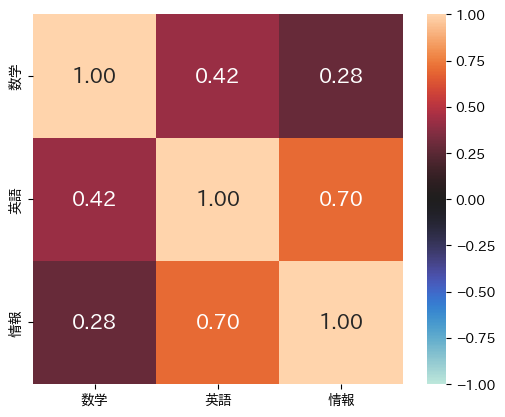

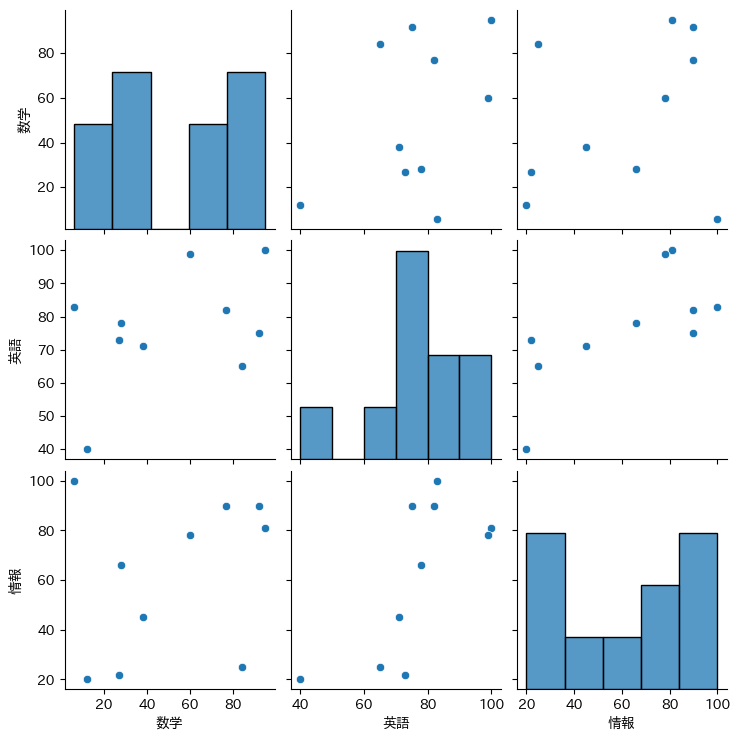

In [5]:
# matplotlibというライブラリはグラフの描画をするためのものである。
# 実行すると、しばらくメッセージが表示される。
import matplotlib.pyplot as plt
# japanize-matplotlib は、matplotlib のグラフで日本語の文字を使うためのものである。
!pip install japanize-matplotlib
import japanize_matplotlib
# seaborn は相関分析に用いる
import seaborn as sns
# pandas はデータフレームに用いる
import pandas as pd

# 科目名
kamokumei_ja = ('数学', '英語', '情報')

# 一人ひとりの、数学、英語、情報の 得点
scores = (
		(77, 82, 90),
    	(92, 75, 90),
        (12, 40, 20),
        (27, 73, 22),
        (84, 65, 25),
        (95, 100, 81),
        (28, 78, 66),
        (60, 99, 78),
        (38, 71, 45),
        (6, 83, 100)
)

# データフレームを定義
df = pd.DataFrame(scores, columns = kamokumei_ja)
print(df)

# 相関係数を表示
print(df.corr(method = 'pearson'))

# ヒートマップを表示
corr_mat = df.corr(method = 'pearson')
sns.heatmap(
	corr_mat,
	cbar = True,
	square = True,
	vmin = -1.0,
	vmax =  1.0,
	center = 0,
	annot = True,
	annot_kws={'size':15},
	fmt='.2f',
	xticklabels = corr_mat.columns.values,
	yticklabels = corr_mat.columns.values,
)

# 散布図行列を表示
sns.pairplot(df)

元のデータが、受験者ごとのリストではなく、科目ごとのリストになっている場合は、転置（行と列を入れ替える）をすることでデータフレームを作ることができる。次のプログラムの24行目で、転置をしている。

【プログラム5404】

   数学   英語   情報
0  77   82   90
1  92   75   90
2  12   40   20
3  27   73   22
4  84   65   25
5  95  100   81
6  28   78   66
7  60   99   78
8  38   71   45
9   6   83  100
          数学        英語        情報
数学  1.000000  0.420220  0.281329
英語  0.420220  1.000000  0.702941
情報  0.281329  0.702941  1.000000


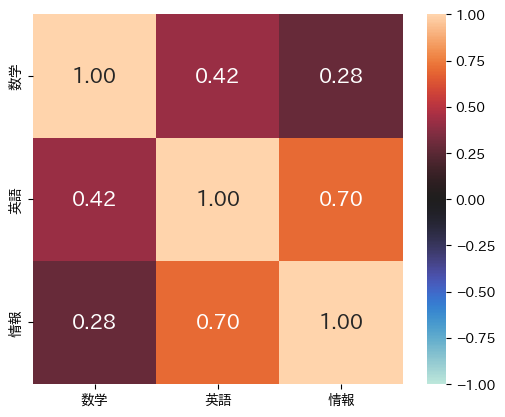

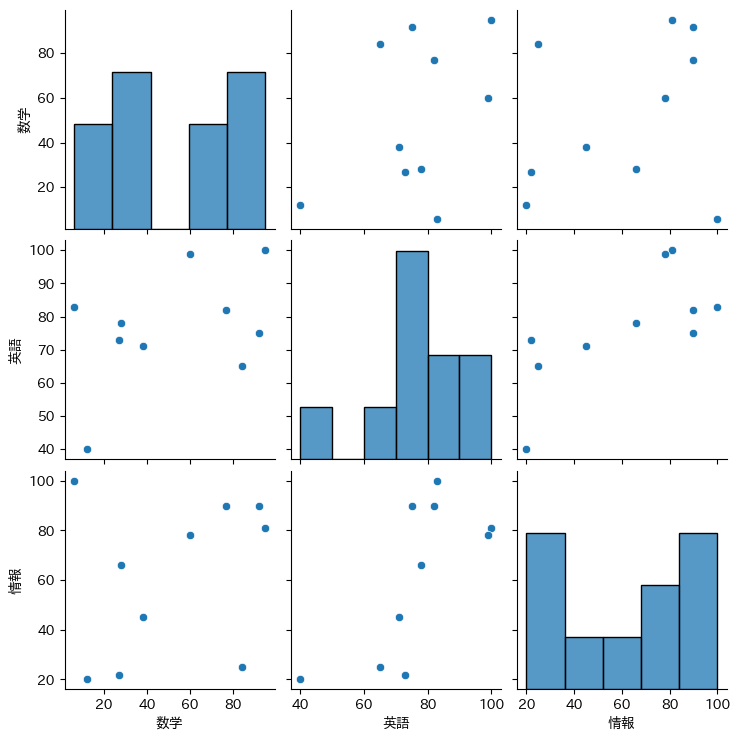

In [6]:
# matplotlibというライブラリはグラフの描画をするためのものである。
# 実行すると、しばらくメッセージが表示される。
import matplotlib.pyplot as plt
# japanize-matplotlib は、matplotlib のグラフで日本語の文字を使うためのものである。
!pip install japanize-matplotlib
import japanize_matplotlib
# seaborn は相関分析に用いる
import seaborn as sns
# pandas はデータフレームに用いる
import pandas as pd

# 数学の点数
math = (77, 92, 12, 27, 84, 95, 28, 60, 38, 6)
# 英語の点数
english = (82, 75, 40, 73, 65, 100, 78, 99, 71, 83)
# 情報の点数
informatics = (90, 90, 20, 22, 25, 81, 66, 78, 45, 100)

# 科目名
kamokumei = (math, english, informatics)
kamokumei_ja = ('数学', '英語', '情報')

# 元のデータを、「データフレーム」にする。このとき、行列の行と列を入れ替えるために、最後に".T"を付けている。
df = pd.DataFrame(kamokumei, index = kamokumei_ja).T

# データフレームを表示
print(df)

# 相関係数を表示
print(df.corr(method = 'pearson'))

# ヒートマップを表示
corr_mat = df.corr(method = 'pearson')
sns.heatmap(
	corr_mat,
	cbar = True,
	square = True,
	vmin = -1.0,
	vmax =  1.0,
	center = 0,
	annot = True,
	annot_kws={'size':15},
	fmt='.2f',
	xticklabels = corr_mat.columns.values,
	yticklabels = corr_mat.columns.values,
)

# 散布図行列を表示
sns.pairplot(df)

### 確認問題　（確認問題の正答はありません。授業中に提示します）

1. 上記のプログラムを実行して、わかったことを述べよ。
2. 上記のプログラムに追記して、例えば、物理の点数を加えて考察せよ。物理の点数として、以下のものを用いてもよいが、ダミーなのでいじってもかまわない。

In [ ]:
physics = (63, 79, 88, 6, 45, 26, 80, 82, 11, 86)

## 研究問題（解答はありません。）

自らの周りのデータを、このようにして分析して、様々なことを発見しなさい。

## データ分析のサンプル

Python のモジュール seaborn には、オーストラリアによる「ペンギン」の調査データが、サンプルデータとして提供されている。
* ペンギンの種類 species
 * Gentoo(ジェンツーペンギン)
 * Chinstrap(ヒゲペンギン)
 * Adelie(アデリーペンギン)
* island 島
* bill_length（くちばしの長さ）, bill_depth(くちばしの太さ), flipper_length（翼の長さ）
* bosy_mass(体重), sex（性別）

【プログラム5405】

344

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


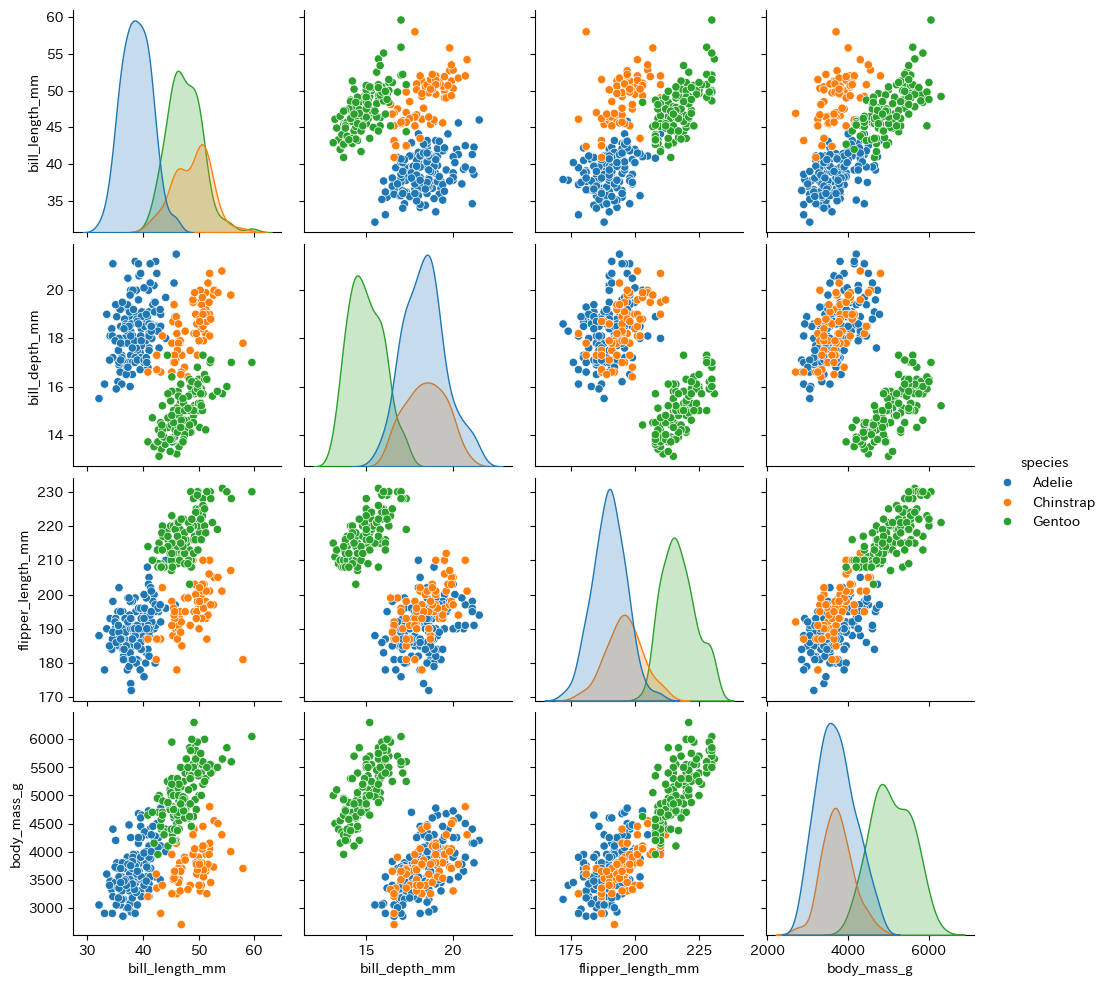

In [7]:
# seaborn は相関分析に用いる
import seaborn as sns
# pandas はデータフレームに用いる
import pandas as pd

# データフレーム df を定義する
df = sns.load_dataset('penguins')

# データ数を表示
print(len(df))
print("")

# データの冒頭5件を表示
print(df.head(5))

# 散布図行列を表示
sns.pairplot(df, hue='species')

### 確認問題　（確認問題の正答はありません。授業中に提示します）

上記のデータからわかったことを述べよ。